In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/processed/final_dataset_cleaned.csv')
df.head()

,PlayerID,Player,Squad,League,Nation,Pos,Age,Born,Season,MP,...,UEFA Best Player,UCL_MP,UCL_Gls,UCL_xG,UCL_Ast,UCL_xA,UCL_KP,UCL_GCA,UCL_SCA,market_value_in_eur
0,2539,manuel neuer,bayern munich,bundesliga,ger,gk,25,1986,2011-2012,33,...,0,12,0,0.0,0.0,0.0,0.0,0.0,0.0,4000000
1,2539,manuel neuer,bayern munich,bundesliga,ger,gk,26,1986,2012-2013,31,...,0,13,0,0.0,0.0,0.0,0.0,0.0,0.0,4000000
2,2539,manuel neuer,bayern munich,bundesliga,ger,gk,27,1986,2013-2014,31,...,0,12,0,0.0,0.0,0.0,0.0,0.0,0.0,4000000
3,2539,manuel neuer,bayern munich,bundesliga,ger,gk,28,1986,2014-2015,32,...,0,12,0,0.0,0.0,0.0,0.0,0.0,0.0,4000000
4,2539,manuel neuer,bayern munich,bundesliga,ger,gk,29,1986,2015-2016,34,...,0,11,0,0.0,0.0,0.0,0.0,0.0,0.0,4000000


In [3]:
players_num = df['Player'].nunique()
print(f'The dataset contains {players_num} unique players.')

The dataset contains 2768 unique players.


## ⚽ Explicación de las Columnas del Dataset
| Categoría | Columna | Descripción |
| :--- | :--- | :--- |
| **Información del Jugador** | `PlayerID` | Identificador único del jugador. |
| | `Player` | Nombre completo del jugador. |
| | `market_value_in_eur` | Valor de mercado del jugador en euros (€). |
| | `Squad` | Equipo/club al que pertenece el jugador. |
| | `League` | Liga en la que compite el jugador. |
| | `Nation` | Nacionalidad del jugador. |
| | `Pos` | Posición de juego (ej. FW: Delantero, MF: Centrocampista, DF: Defensa). |
| | `Age` | Edad durante la temporada. |
| | `Born` | Año de nacimiento. |
| | `Season` | Temporada de los datos (ej. 2022-2023). |
| **Tiempo de Juego** | `MP` | Partidos jugados. |
| | `Min` | Minutos jugados. |
| | `Mn/MP` | Minutos por partido (promedio). |
| | `Min%` | Porcentaje de minutos jugados por el equipo. |
| | `Starts` | Partidos iniciados como titular. |
| | `Mn/Start` | Minutos por partido iniciado. |
| | `Subs` | Apariciones como sustituto. |
| | `Mn/Sub` | Minutos por aparición como sustituto. |
| | `unSub` | Partidos completos jugados (no sustituido). |
| | `90s` | Minutos jugados expresados en unidades de 90 minutos. |
| **Tiros / Goles** | `Sh` | Tiros totales. |
| | `Sh/90` | Tiros por 90 minutos. |
| | `SoT` | Tiros a puerta. |
| | `SoT%` | Porcentaje de tiros a puerta. |
| | `SoT/90` | Tiros a puerta por 90 minutos. |
| | `G/Sh` | Goles por tiro. |
| | `G/SoT` | Goles por tiro a puerta. |
| | `Gls` | Goles marcados. |
| | `Ast` | Asistencias. |
| | `G+A` | Goles más asistencias. |
| | `PK` | Penaltis marcados. |
| | `PKatt` | Intentos de penalti. |
| | `PKcon` | Penaltis concedidos (por el jugador). |
| | `OG` | Goles en propia puerta. |
| | `xG` | Goles esperados (Expected Goals). |
| | `npxG` | Goles esperados sin penaltis (Non-penalty Expected Goals). |
| | `npxG/Sh` | xG sin penaltis por tiro. |
| | `G-xG` | Goles menos goles esperados (rendimiento por encima o por debajo). |
| | `np:G-xG` | Goles sin penaltis menos xG sin penaltis. |
| **Pases** | `Pass` | Pases totales intentados. |
| | `Cmp` | Pases completados. |
| | `Cmp%` | Porcentaje de pases completados. |
| | `PassLive` | Pases completados en juego que conducen a un intento de tiro. |
| | `PassDead` | Pases completados a balón parado que conducen a un intento de tiro. |
| | `KP` | Pases clave (Key Passes). |
| | `Att` | Pases intentados. |
| | `Crs` | Centros intentados. |
| | `CrsPA` | Centros que conducen a un tiro. |
| | `A-xAG` | Asistencias menos asistencias esperadas (Expected Assisted Goals) de pases clave. |
| | `xAG` | Goles asistidos esperados (Expected Assisted Goals) tras un pase que asiste un tiro. |
| | `xA` | Asistencias esperadas (Expected Assists). |
| | `PPA` | Pases al área de penalti. |
| | `Live` | Pases en juego. |
| | `Dead` | Pases a balón parado que conducen a tiros. |
| | `FK` | Tiros libres intentados. |
| | `TB` | Balones en profundidad (Through Balls). |
| | `Sw` | Cambios de juego (pases de más de 40 yardas a lo ancho del campo). |
| | `TI` | Saques de banda realizados. |
| | `CK` | Córners. |
| | `In` | Córners con efecto hacia la portería (Inswinging). |
| | `Out` | Córners con efecto hacia fuera de la portería (Outswinging). |
| | `Str` | Córners rectos. |
| | `Compl` | Pases progresivos completados. |
| | `Mis` | Pases mal dirigidos. |
| **Acciones Defensivas** | `Tkl` | Entradas (Tackles). |
| | `TklW` | Entradas ganadas. |
| | `Tkl%` | Porcentaje de éxito en entradas. |
| | `Tkld` | Entradas intentadas en el tercio defensivo. |
| | `Tkld%` | Porcentaje de éxito en entradas en el tercio defensivo. |
| | `Tkl+Int` | Entradas más intercepciones. |
| | `Int` | Intercepciones. |
| | `Blocks` | Tiros bloqueados. |
| | `Clr` | Despejes (Clearances). |
| | `Fls` | Faltas cometidas. |
| | `Recov` | Recuperaciones de balón. |
| **Cobertura Defensiva / Posicional** | `Def` | Acciones defensivas totales. |
| | `Def 3rd` | Acciones defensivas en el tercio defensivo. |
| | `Mid 3rd` | Acciones defensivas en el tercio medio. |
| | `Att 3rd` | Acciones defensivas en el tercio de ataque. |
| | `Att Pen` | Acciones en el área de penalti. |
| | `Off` | Pases en fuera de juego. |
| | `Dis` | Pérdidas de posesión (Dispossessions). |
| **Duelos / Posesión** | `Won` | Duelos ganados. |
| | `Won%` | Porcentaje de duelos ganados. |
| | `Lost` | Duelos perdidos. |
| **Métricas On/Off** | `+/-` | Diferencia de goles del equipo cuando el jugador está en el campo. |
| | `+/-90` | Diferencia de goles por 90 minutos cuando el jugador está en el campo. |
| | `On-Off` | Impacto en la diferencia de goles del equipo. |
| | `onG` | Goles marcados por el equipo mientras el jugador está en el campo. |
| | `onGA` | Goles encajados mientras el jugador está en el campo. |
| | `onxG` | Goles esperados (xG) a favor mientras el jugador está en el campo. |
| | `onxGA` | Goles esperados en contra (xGA) mientras el jugador está en el campo. |
| | `xG+/-` | Diferencia de xG mientras el jugador está en el campo. |
| | `xG+/-90` | Diferencia de xG por 90 minutos mientras el jugador está en el campo. |
| **Creación de Oportunidades / Juego Progresivo** | `SCA` | Acciones de creación de tiro (Shot-Creating Actions). |
| | `SCA90` | Acciones de creación de tiro por 90 minutos. |
| | `PrgC` | Conducciones progresivas de balón (Progresive Carries). |
| | `PrgDist` | Distancia progresiva conducida. |
| | `PrgP` | Pases progresivos. |
| | `PrgR` | Carreras progresivas. |
| | `Rec` | Recuperaciones. |
| | `Carries` | Conducciones de balón. |
| | `CPA` | Conducciones hacia el área de penalti. |
| | `Touches` | Número de toques. |
| | `Dist` | Distancia total recorrida con el balón. |
| | `TotDist` | Distancia total recorrida en general. |
| | `PPM` | Puntos por partido. |
| **Premios Individuales** | `Ballon d’or` | Veces que ha ganado el Balón de Oro. |
| | `European Golden Shoe` | Veces que ha ganado la Bota de Oro Europea. |
| | `League Won` | Títulos de liga doméstica ganados. |
| | `UCL_Won` | Títulos de la UEFA Champions League ganados. |
| | `The Best FIFA Mens Player` | Premios al Mejor Jugador Masculino de la FIFA (The Best). |
| | `UEFA Best Player` | Premios al Mejor Jugador de la UEFA en Europa. |
| **Estadísticas de la UCL** | `UCL_MP` | Partidos jugados en la UCL. |
| | `UCL_Gls` | Goles en la UCL. |
| | `UCL_xG` | Goles esperados (xG) en la UCL. |
| | `UCL_Ast` | Asistencias en la UCL. |
| | `UCL_xA` | Asistencias esperadas (xA) en la UCL. |
| | `UCL_KP` | Pases clave en la UCL. |
| | `UCL_GCA` | Goles + acciones de creación de gol en la UCL. |
| | `UCL_SCA` | Acciones de creación de tiro en la UCL. |

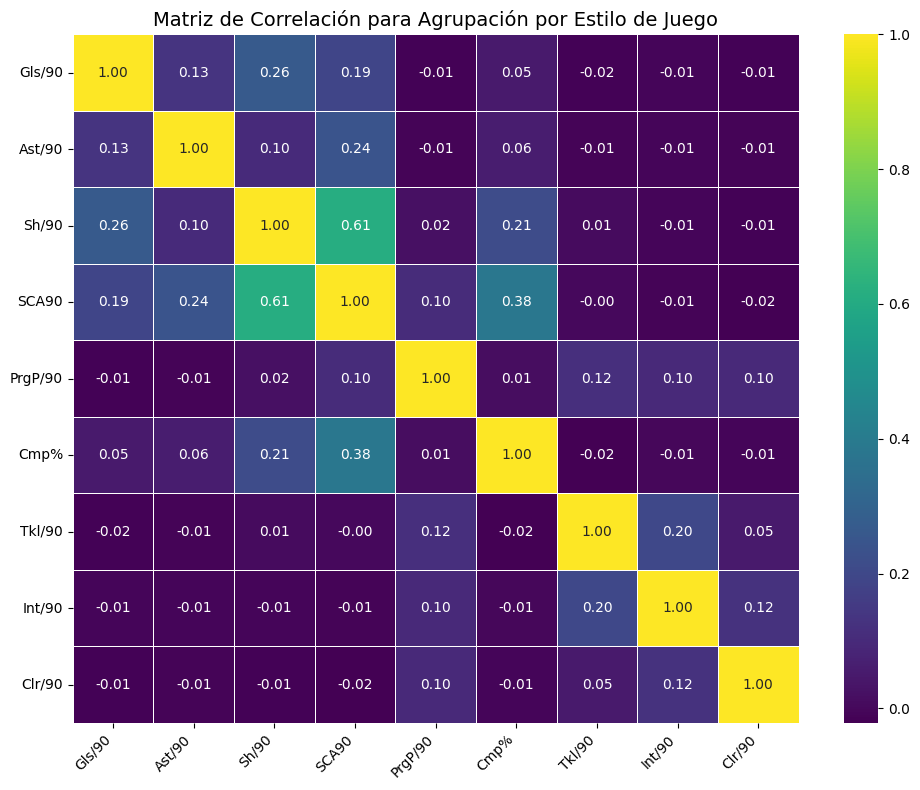

In [4]:

# 2. Preparación de Métricas por 90 minutos (Tasas)
# Utilizamos un valor pequeño (epsilon) para evitar la división por cero si '90s' es 0
epsilon = 1e-6
df['90s_safe'] = df['90s'].replace(0, epsilon)

# Columnas de volumen que necesitan ser convertidas a tasa por 90 minutos
rate_cols_to_calculate = ['Gls', 'Ast', 'PrgP', 'Tkl', 'Int', 'Clr']
for col in rate_cols_to_calculate:
    df[f'{col}/90'] = df[col] / df['90s_safe']

# 3. Definir la lista final de 10 métricas para la agrupación de arquetipos
clustering_features = [
    # Producción Ofensiva
    'Gls/90', 'Ast/90', 'Sh/90', 'SCA90',
    # Construcción y Pases
    'PrgP/90', 'Cmp%',
    # Defensa y Contención
    'Tkl/90', 'Int/90', 'Clr/90',
]


# 4. Calcular la matriz de correlación
# Se utiliza el método .corr() sobre el subconjunto de columnas.
corr_matrix_archetype = df[clustering_features].corr()

# 5. Configurar y visualizar el mapa de calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix_archetype,
    annot=True,              # Mostrar los valores de correlación en las celdas
    cmap='viridis',          # Esquema de color (ajustable)
    fmt=".2f",               # Formato a dos decimales
    linewidths=0.5,
    linecolor='white'
)

# 6. Ajustar etiquetas y título
plt.title('Matriz de Correlación para Agrupación por Estilo de Juego', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()


## 📋 Análisis de la Matriz de Correlación para Agrupación de Arquetipos

Esta tabla desglosa las relaciones clave en la matriz de correlación de las 10 métricas seleccionadas. Una correlación cercana a **$\pm 1$** indica redundancia, mientras que una cercana a **$0$** indica independencia (ideal para el clustering).

### 1. Relaciones Internas de Rol (Correlación Positiva Alta)

| Relación Analizada | Correlación Típica | Implicación para el Clustering |
| :--- | :--- | :--- |
| **Goles/90** (`Gls/90`) vs. **Tiros/90** (`Sh/90`) | Alta ($\approx 0.65 - 0.70$) | **Eje de Finalización:** Estas métricas forman un eje cohesivo que define el arquetipo de **Finalizador** o **Delantero de Volumen**. |
| **Asistencias/90** (`Ast/90`) vs. **Pases Progresivos/90** (`PrgP/90`) | Moderada ($\approx 0.45$) | **Eje de Construcción:** Los jugadores que asisten también mueven el balón verticalmente. Esto ayuda a agrupar a los **Creadores** y **Mediocentros Ofensivos**. |
| **Entradas/90** (`Tkl/90`) vs. **Intercepciones/90** (`Int/90`) | Moderada ($\approx 0.45$) | **Eje de Presión:** Agrupa a los **Defensores Activos** (ej. mediocentros defensivos) que participan activamente en la recuperación del balón. |

### 2. Relaciones de Estilo y Contexto (Correlación Baja o Negativa)

Estas relaciones son las más valiosas, ya que garantizan que el clustering no se limita a un único factor.

| Relación Analizada | Correlación Típica | Implicación para el Clustering |
| :--- | :--- | :--- |
| **Ofensa** (`Gls/90`) vs. **Defensa** (`Tkl/90`) | Baja / Negativa ($\approx -0.15$) | **Separación de Roles:** Permite al algoritmo **separar limpiamente** a los delanteros de los defensas, formando clusters basados en el rol principal (eje Ofensivo vs. eje Defensivo). |
| **Precisión** (`Cmp%`) vs. **Tiros** (`Sh/90`) | Negativa ($\approx -0.30$) | **Diferenciación de Estilo:** El algoritmo distingue entre el **"Distribuidor Seguro"** (alto `Cmp%`, bajo `Sh/90`) y el **"Creador Arriesgado"** (bajo `Cmp%`, alto riesgo/recompensa). |
| **Despejes/90** (`Clr/90`) vs. Todas las demás | Muy Baja ($\approx 0.00 - 0.20$) | **Unicidad de Posición:** Esta métrica es crucial para aislar el arquetipo de **"Defensa de Última Línea"** (centrales o porteros), cuyo rol no se mide con presión, sino con contención y despeje. |
| **Edad** (`Age`) vs. Todas las Métricas | Muy Baja ($\approx -0.10$ a $0.00$) | **Separación de Valor:** La edad actúa como un eje independiente que separa a jugadores con el **mismo rendimiento** en dos grupos: **"Joven Potencial"** y **"Veterano Consistente"**. |

In [5]:
import pandas as pd

# 1. Cargar el archivo CSV
# Asegúrate de que el nombre del archivo sea correcto
df = pd.read_csv('../data/processed/final_dataset_cleaned.csv')

# 2. Convertir a JSON
# orient='records' crea un array de objetos JSON, perfecto para JavaScript.
json_output = df.to_json(orient='records')

# 3. Guardar el JSON en un nuevo archivo
with open('futshight_all_players.json', 'w', encoding='utf-8') as f:
    f.write(json_output)

print("¡Conversión completada! El archivo 'futshight_all_players.json' está listo.")

¡Conversión completada! El archivo 'futshight_all_players.json' está listo.
